In [2]:
import pandas as pd

In [7]:
df = pd.read_csv("data/dat_train2.csv", nrows=10)

In [6]:
df.head()

,customer_id,account_id,ed_id,event_name,event_timestamp,journey_steps_until_end,id,sep
0,15849251,383997507,4,browse_products,2021-11-04T14:11:15Z,1,15849251 383997507,-
1,15849251,383997507,4,browse_products,2021-11-04T14:11:29Z,2,15849251 383997507,-
2,15849251,383997507,4,browse_products,2021-11-04T14:12:10Z,3,15849251 383997507,-
3,15849251,383997507,4,browse_products,2021-11-04T14:12:21Z,4,15849251 383997507,-
4,15849251,383997507,4,browse_products,2021-11-04T14:12:24Z,5,15849251 383997507,-


In [3]:
df2 = pd.read_parquet("data/train_data2_flattened.parquet")

In [4]:
df2['customer_id'] = df2['id'].apply(lambda x: x.split(' ')[0])

In [26]:
import matplotlib.pyplot as plt

In [27]:
100 * (df2['customer_id'].value_counts() > 1).sum() / df2['customer_id'].nunique()

np.float64(3.4627347882967117)

In [20]:
df2['successful'] = [28 in row.events for row in df2.itertuples(index=False)]

Only about 3.5% of customers have multiple journeys. Let's see if those customers are more likely to have successful journeys.

In [16]:
multiple_customers = df2['customer_id'].value_counts().index[df2['customer_id'].value_counts() > 1]
single_customers = df2['customer_id'].value_counts().index[df2['customer_id'].value_counts() == 1]

In [21]:
df2.head()

,id,events,event_names,timestamps,journey_length,customer_id,successful
0,-1000001271 551641434,"[12, 4, 19, 19, 19, 2, 4]","[application_web_approved, browse_products, ap...","[2022-10-31T13:45:59.000000, 2022-10-31T13:47:...",7,-1000001271,False
1,-100000293 92584960,"[12, 4, 4, 4, 4, 4, 4, 4, 11, 4, 4, 11, 4, 11,...","[application_web_approved, browse_products, br...","[2021-11-11T01:30:43.000000, 2021-11-11T01:39:...",31,-100000293,False
2,-100001025 -1674572031,"[2, 19, 1, 19, 19, 19, 19, 19, 19, 19, 3, 19, ...","[campaign_click, application_web_view, promoti...","[2022-05-09T06:00:00.000000, 2022-05-09T13:10:...",26,-100001025,False
3,-1000011207 -1448136887,"[12, 4, 11, 5, 5, 5, 4, 5, 4, 4, 4, 4, 1, 4, 4...","[application_web_approved, browse_products, ad...","[2021-03-21T11:19:48.000000, 2021-03-21T11:27:...",61,-1000011207,False
4,-100001164 -1710062169,[15],[application_phone_approved],[2022-12-02T07:45:16.000000],1,-100001164,False


In [22]:
df2.loc[df2['customer_id'].isin(multiple_customers), 'successful'].mean()

np.float64(0.13852903712789547)

In [ ]:
# Proportion Successful for 1 journey
df2.loc[df2['customer_id'].isin(single_customers), 'successful'].mean()

np.float64(0.19650980811643692)

In [28]:
# Proportion Successful for 2 journeys
df2.loc[df2['customer_id'].isin(df2['customer_id'].value_counts().index[df2['customer_id'].value_counts() == 2]), 'successful'].mean()

np.float64(0.13910266276743113)

Questions:

1. What proportion of people who have a successful first journey have a successful second journey?
2. What proportion of second journeys are successful (for people that have two or more journeys)?


New Features to include:
1. Number of previous journeys (for the user)
2. Number of successful journeys (for the user)

In [37]:
exactly2 = df2[df2['customer_id'].isin(df2['customer_id'].value_counts().index[df2['customer_id'].value_counts() == 2])].copy()

In [41]:
exactly2['start_date'] = [row.timestamps[0] for row in exactly2.itertuples(index=False)]

In [42]:
exactly2.head()

,id,events,event_names,timestamps,journey_length,customer_id,successful,start_date
48,-1000140359 1672935802,"[12, 1, 4, 3, 19, 11, 2]","[application_web_approved, promotion_created, ...","[2023-04-23T10:45:23.000000, 2023-04-23T11:27:...",7,-1000140359,False,2023-04-23 10:45:23
49,-1000140359 1713232320,"[2, 19, 19, 19, 19, 19, 19, 3, 19, 12, 21, 1, ...","[campaign_click, application_web_view, applica...","[2022-03-22T06:00:00.000000, 2022-03-22T11:07:...",56,-1000140359,False,2022-03-22 06:00:00
105,-1000270768 -1635387216,"[19, 19, 19, 19, 19, 19, 19, 3, 19, 19, 3, 19,...","[application_web_view, application_web_view, a...","[2022-06-24T17:59:46.000000, 2022-06-24T17:59:...",29,-1000270768,False,2022-06-24 17:59:46
106,-1000270768 178066892,"[19, 3, 19, 19, 3, 19, 19, 12, 19, 4, 4, 4, 4,...","[application_web_view, application_web_submit,...","[2021-06-01T11:11:34.000000, 2021-06-01T11:13:...",179,-1000270768,False,2021-06-01 11:11:34
120,-100030883 1031184113,"[19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 1...","[application_web_view, application_web_view, a...","[2021-10-05T03:45:38.000000, 2021-10-05T03:45:...",54,-100030883,False,2021-10-05 03:45:38


In [44]:
df_sorted = exactly2.sort_values(['customer_id', 'start_date'])

first_journeys = df_sorted.groupby('customer_id', as_index=False).nth(0)
second_journeys = df_sorted.groupby('customer_id', as_index=False).nth(1)

In [ ]:
# Proportion of first journey (out of 2) success rate
first_journeys['successful']

np.float64(0.10631830075419424)

In [ ]:
# Proportion of second journey (out of 2) success rate
second_journeys['successful'].mean()

np.float64(0.171887024780668)

In [55]:
# Proportion of successful second journey if successful first journey
second_journeys.loc[second_journeys['customer_id'].isin(first_journeys.loc[first_journeys['successful'], 'customer_id']), 'successful'].mean()

np.float64(0.29768367716250455)

In [35]:
df2.loc[df2['customer_id'].isin(df2['customer_id'].value_counts().index[df2['customer_id'].value_counts() == 3]), 'successful'].shape

(1953,)

In [33]:
# Proportion Successful for 3 journeys
df2.loc[df2['customer_id'].isin(df2['customer_id'].value_counts().index[df2['customer_id'].value_counts() >= 3]), 'successful'].mean()

np.float64(0.10919822921790458)

In [31]:
# Proportion Successful for 4 journeys
df2.loc[df2['customer_id'].isin(df2['customer_id'].value_counts().index[df2['customer_id'].value_counts() == 4]), 'successful'].mean()

np.float64(0.15)

In [32]:
# Proportion Successful for 5 journeys
df2.loc[df2['customer_id'].isin(df2['customer_id'].value_counts().index[df2['customer_id'].value_counts() == 5]), 'successful'].mean()

np.float64(0.1)

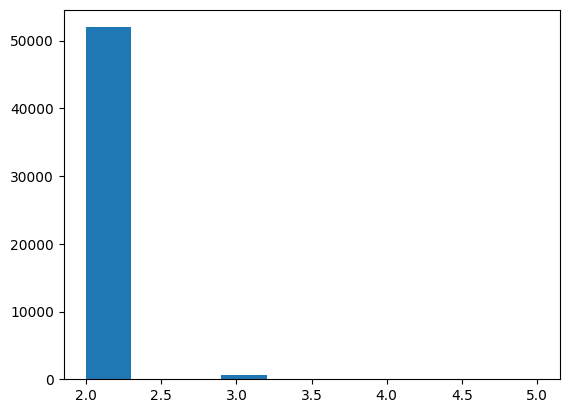

In [27]:
plt.hist(df2['customer_id'].value_counts()[df2['customer_id'].value_counts() > 1])
plt.show()

In [33]:
df2.head()

,id,events,event_names,timestamps,journey_length,customer_id,successful
0,-1000001271 551641434,"[12, 4, 19, 19, 19, 2, 4]","[application_web_approved, browse_products, ap...","[2022-10-31T13:45:59.000000, 2022-10-31T13:47:...",7,-1000001271,False
1,-100000293 92584960,"[12, 4, 4, 4, 4, 4, 4, 4, 11, 4, 4, 11, 4, 11,...","[application_web_approved, browse_products, br...","[2021-11-11T01:30:43.000000, 2021-11-11T01:39:...",31,-100000293,False
2,-100001025 -1674572031,"[2, 19, 1, 19, 19, 19, 19, 19, 19, 19, 3, 19, ...","[campaign_click, application_web_view, promoti...","[2022-05-09T06:00:00.000000, 2022-05-09T13:10:...",26,-100001025,False
3,-1000011207 -1448136887,"[12, 4, 11, 5, 5, 5, 4, 5, 4, 4, 4, 4, 1, 4, 4...","[application_web_approved, browse_products, ad...","[2021-03-21T11:19:48.000000, 2021-03-21T11:27:...",61,-1000011207,False
4,-100001164 -1710062169,[15],[application_phone_approved],[2022-12-02T07:45:16.000000],1,-100001164,False


In [34]:
df2['customer_id'].value_counts()[:5]

customer_id
-1890253381    5
1335383318     5
1959246755     5
643739592      5
-1564628345    4
Name: count, dtype: int64

In [39]:
df2[df2['customer_id'] == '-1564628345']

,id,events,event_names,timestamps,journey_length,customer_id,successful
229633,-1564628345 -1802617844,"[2, 19, 19, 19, 19, 3, 12, 19, 4, 4, 11, 5, 6,...","[campaign_click, application_web_view, applica...","[2021-04-06T06:00:00.000000, 2021-04-06T16:35:...",42,-1564628345,False
229634,-1564628345 -645439655,"[2, 19, 19, 19, 3, 12, 19, 4, 11, 5, 6, 5, 5, ...","[campaign_click, application_web_view, applica...","[2021-04-18T06:00:00.000000, 2021-04-18T19:13:...",62,-1564628345,False
229635,-1564628345 1223755076,"[5, 6, 19, 19, 19, 19, 19, 19, 19, 3, 19, 19, ...","[view_cart, begin_checkout, application_web_vi...","[2022-06-09T01:29:19.000000, 2022-06-09T01:29:...",64,-1564628345,False
229636,-1564628345 876640253,"[19, 19, 19, 3, 19, 19, 3, 19, 19, 3, 12, 4, 1...","[application_web_view, application_web_view, a...","[2021-06-12T19:30:03.000000, 2021-06-12T19:30:...",79,-1564628345,True


In [42]:
df2[df2['customer_id'] == '892710893']

,id,events,event_names,timestamps,journey_length,customer_id,successful
1530069,892710893 -264365398,"[2, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19...","[campaign_click, application_web_view, applica...","[2022-04-09T06:00:00.000000, 2022-04-09T13:29:...",51,892710893,True
1530070,892710893 1163349240,"[24, 2, 19, 19, 19, 19, 3, 19, 12, 19, 24, 4, ...","[campaignemail_clicked, campaign_click, applic...","[2021-03-27T08:04:24.000000, 2021-04-17T06:00:...",27,892710893,True
1530071,892710893 1930825810,"[5, 5, 4, 5, 4, 11, 4, 4, 5, 5, 6, 19, 19, 19,...","[view_cart, view_cart, browse_products, view_c...","[2022-12-31T17:51:25.000000, 2022-12-31T17:51:...",29,892710893,True


In [52]:
df2.loc[(df2['successful']) & (df2['journey_length'] < 2)].head()

,id,events,event_names,timestamps,journey_length,customer_id,successful
12485,-1031281918 -107212326,[28],[order_shipped],[2021-10-16T00:00:00.000000],1,-1031281918,True
17894,-1044813842 -45247693,[28],[order_shipped],[2021-08-26T00:00:00.000000],1,-1044813842,True
21580,-1053652528 -1662718424,[28],[order_shipped],[2021-12-16T00:00:00.000000],1,-1053652528,True
54554,-1134258415 1152189848,[28],[order_shipped],[2022-01-25T00:00:00.000000],1,-1134258415,True
101927,-1250795242 -56132357,[28],[order_shipped],[2021-03-31T00:00:00.000000],1,-1250795242,True


In [48]:
df2.loc[(df2['successful']) & (df2['journey_length'] < 2), 'customer_id'].unique()

array(['-1031281918', '-1044813842', '-1053652528', '-1134258415',
       '-1250795242', '-1396211966', '-1489269381', '-15339029',
       '-1596810468', '-1644787622', '-1683699586', '-1908513498',
       '-19586424', '-2082258009', '-245722789', '-409384009',
       '-422813547', '-436565984', '-452680715', '-497606264',
       '-663410481', '-669450644', '-776495868', '-836242375',
       '1087516380', '1160185538', '1280038216', '1388528162',
       '1597376535', '1681597629', '1720142058', '176180384',
       '1835493775', '1990496979', '327454585', '464596295', '78448045',
       '989334325'], dtype=object)

In [49]:
for customer_id in df2.loc[(df2['successful']) & (df2['journey_length'] < 2), 'customer_id'].unique():
    print(f"Customer has {df2[df2['customer_id'] == customer_id].shape[0]} journeys")

Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 2 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 3 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 1 journeys
Customer has 2 journeys
Customer has 1 journeys


In [43]:
df2[df2['customer_id'] == '-452680715']

,id,events,event_names,timestamps,journey_length,customer_id,successful
564261,-452680715 -1695446860,[28],[order_shipped],[2023-04-07T00:00:00.000000],1,-452680715,True
564262,-452680715 1703705066,"[12, 4, 4, 11, 4, 11, 4, 4, 4, 4, 4, 4, 11, 4,...","[application_web_approved, browse_products, br...","[2021-02-28T10:38:17.000000, 2021-02-28T10:45:...",68,-452680715,True
564263,-452680715 229466377,"[2, 19, 19, 19, 19, 19, 19, 19, 19, 3, 19, 3, ...","[campaign_click, application_web_view, applica...","[2022-02-17T06:00:00.000000, 2022-02-17T19:26:...",122,-452680715,True


In [41]:
df2.groupby('customer_id')['successful'].sum().sort_values(ascending=False).head(n=10)

customer_id
892710893      3
-452680715     3
-1735722206    3
1591871066     2
770631922      2
-1082212243    2
2067784443     2
502080198      2
1455635101     2
1554403255     2
Name: successful, dtype: int64